<a href="https://colab.research.google.com/github/hi-wesley/cohere-ml-understanding/blob/main/Session_2_early_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This assignment is based on the 'An Overview of Early Vision in InceptionV1' article [https://distill.pub/2020/circuits/early-vision/] from the Circuits thread by Distill publication.




---



# Lucent (Lucid for Pytorch) Library

Lucent library, provides a higher-level interface for visualizing neuron activations. The render_vis function from Lucent automates the process of activation maximization and visualization.

Why does Lucid(Used in Circuits thread visualizations)/Lucent work so much better as showing us 'Interpretable visualizations'?
Lucent uses a technique called feature visualization, which is a way to visualize what a deep learning model has learned. It does this by optimizing an input image to maximize the activations of specific neurons in the model. The optimization process is guided by a loss function that encourages the model to produce high activations for the chosen neurons.

However, simply maximizing the activations can lead to noisy, uninterpretable images. To get more interpretable images, Lucent incorporates several regularization techniques into the optimization process. These techniques encourage the optimized image to have certain desirable properties, such as smoothness, sparsity, or naturalness.

One of the key regularization techniques used by Lucent is called transformation robustness. This technique encourages the optimized image to activate the chosen neurons even when the image is slightly transformed, such as by translating, rotating, or scaling the image. This encourages the model to focus on the high-level features that are invariant to these transformations, rather than on low-level, transformation-sensitive features.

Another technique used by Lucent is called jitter, which adds a small amount of random noise to the image at each step of the optimization process. This helps to prevent the model from overfitting to the specific pixel values of the image, and encourages it to focus on the high-level features.

By combining these and other techniques, Lucent is able to generate beautiful, interpretable images that give us insight into what a deep learning model has learned.

In [1]:
#Install Lucent
# !pip install torch-lucent



---



In [2]:
## Imports
# import lucent
# from lucent.optvis import render, param, transform, objectives

# import torch
# import torch.nn as nn
# import torchvision.models as models
# from torchvision import transforms

# import matplotlib.pyplot as plt
# from PIL import Image



---



## TASK 1

### Neuron-Level Analysis: What Does This Unit Represent?

In this task, we will ll explore the interpretability of an individual neuron/unit in an early convolutional layer of a pre-trained model.

#### Steps:
1. **Select a random neuron (unit)** from an early convolutional layer of the model.
2. **Use Lucent** library to perform **activation maximization** for this unit.
3. **Identify dataset images** that **strongly activate this neuron**.
4. **Compare** the activation-maximized images with the real dataset images:
   - Do they exhibit similar textures, colors, or patterns?
   - Can you infer a consistent visual feature the neuron is responding to?

> Based on both the activation maximization result and the most activating dataset images,  
> can you make a **concrete claim** about what this neuron represents?


## Layer - conv2d0

In [3]:
!pip install git+https://github.com/greentfrapp/lucent.git

  Cloning https://github.com/greentfrapp/lucent.git to /tmp/pip-req-build-ybcj16b7
  Running command git clone --filter=blob:none --quiet https://github.com/greentfrapp/lucent.git /tmp/pip-req-build-ybcj16b7
  Resolved https://github.com/greentfrapp/lucent.git to commit 2ccc434d80097e58f53cb2a70c60f72902fe93af
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/

100%|██████████| 512/512 [00:15<00:00, 33.36it/s]


dict_keys(['', 'conv2d0_pre_relu_conv', 'conv2d1_pre_relu_conv', 'conv2d2_pre_relu_conv', 'mixed3a_1x1_pre_relu_conv', 'mixed3a_3x3_bottleneck_pre_relu_conv', 'mixed3a_5x5_bottleneck_pre_relu_conv', 'mixed3a_pool_reduce_pre_relu_conv', 'mixed3a_3x3_pre_relu_conv', 'mixed3a_5x5_pre_relu_conv', 'mixed3b_1x1_pre_relu_conv', 'mixed3b_3x3_bottleneck_pre_relu_conv', 'mixed3b_5x5_bottleneck_pre_relu_conv', 'mixed3b_pool_reduce_pre_relu_conv', 'mixed3b_3x3_pre_relu_conv', 'mixed3b_5x5_pre_relu_conv', 'mixed4a_1x1_pre_relu_conv', 'mixed4a_3x3_bottleneck_pre_relu_conv', 'mixed4a_5x5_bottleneck_pre_relu_conv', 'mixed4a_pool_reduce_pre_relu_conv', 'mixed4a_3x3_pre_relu_conv', 'mixed4a_5x5_pre_relu_conv', 'mixed4b_1x1_pre_relu_conv', 'mixed4b_3x3_bottleneck_pre_relu_conv', 'mixed4b_5x5_bottleneck_pre_relu_conv', 'mixed4b_pool_reduce_pre_relu_conv', 'mixed4b_3x3_pre_relu_conv', 'mixed4b_5x5_pre_relu_conv', 'mixed4c_1x1_pre_relu_conv', 'mixed4c_3x3_bottleneck_pre_relu_conv', 'mixed4c_5x5_bottleneck_p

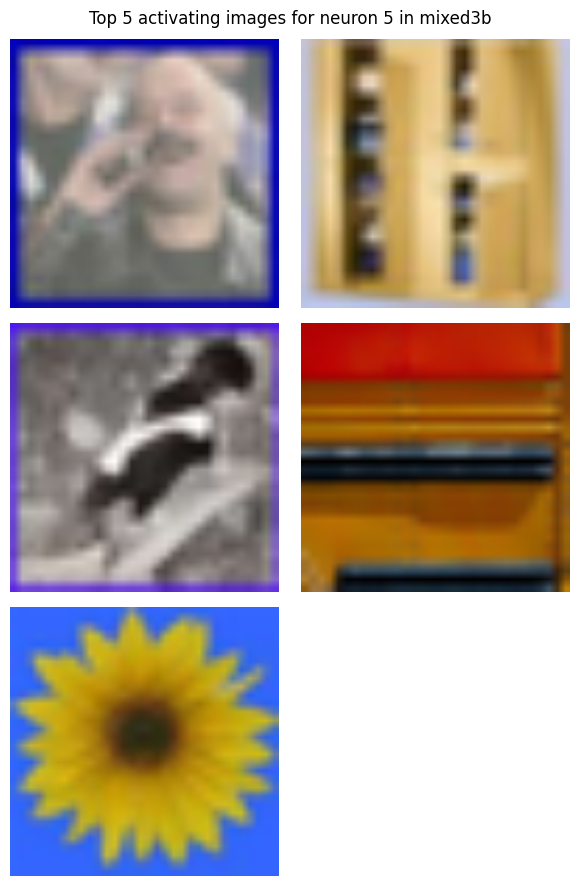

<Figure size 640x480 with 0 Axes>

In [11]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import math
from lucent.optvis import render, param, transform, objectives
from lucent.modelzoo.util import get_model_layers
from lucent.modelzoo import inceptionv1

# model = models.googlenet(pretrained=True).eval().to('cuda')
model = inceptionv1(pretrained=True).eval().to('cuda')

layers = get_model_layers(model)
# print(layers)

layer_name = 'conv2d0'
layer_name = 'conv2d1'
layer_name = 'conv2d2'
layer_name = 'mixed3a'
layer_name = 'mixed3b'
neuron_index = 5

objective = objectives.channel(layer_name, neuron_index)

# Visualization with regularizations: jitter and robustness
vis = render.render_vis(model, objective,
                        param_f=lambda: param.image(128),
                        transforms=[
                            transform.pad(12),
                            transform.jitter(8),
                            transform.random_scale([0.9, 1.1]),
                            transform.random_rotate([-5, 5]),
                            transform.jitter(2),
                        ],
                        thresholds=(512,),
                        show_image=True)

# Define the transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to match Inception input
    transforms.ToTensor()
])

# Automatically download CIFAR-10 (no manual files required), can use CIFAR100 too
dataset = datasets.CIFAR100(root='./data', train=False, transform=transform, download=True)

# DataLoader setup
# avoid running out of memory
# loader = DataLoader(dataset, batch_size=32, shuffle=False)
loader = DataLoader(dataset, batch_size=16, shuffle=False)

activations = []

# Hook function to record activations
def hook_fn(module, input, output):
    # activations.append(output[:, neuron_index].detach().cpu().numpy())
    activations.append(output[:, 5].detach().cpu())

# Attach hook
hook = dict(model.named_modules())[layer_name].register_forward_hook(hook_fn)

# Keep track of top activations and corresponding images
# top_k = 30
top_k = 5
top_activations = []
top_images = []

# Iterate and collect activations
with torch.no_grad():
    for images, _ in loader:
        activations.clear()
        images_cuda = images.cuda()
        model(images_cuda)

        batch_acts = activations[0].numpy()
        for act, img in zip(batch_acts, images):
            max_act = act.mean()  # Mean activation spatially, adjust as desired
            if len(top_activations) < top_k:
                top_activations.append(max_act)
                top_images.append(img)
            else:
                min_idx = np.argmin(top_activations)
                if max_act > top_activations[min_idx]:
                    top_activations[min_idx] = max_act
                    top_images[min_idx] = img

hook.remove()

# Sort images and activations in descending order
sorted_indices = np.argsort(top_activations)[::-1]
top_images = [top_images[i] for i in sorted_indices]
top_activations = [top_activations[i] for i in sorted_indices]

num_images = len(top_images)

# Determine grid size (rows, columns)
cols = int(math.sqrt(num_images))
rows = math.ceil(num_images / cols)

fig, axs = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

# Flatten axs for easy indexing if multiple rows
axs = axs.flatten() if num_images > 1 else [axs]

for i in range(len(axs)):
    if i < num_images:
        img_np = top_images[i].permute(1, 2, 0).numpy()
        axs[i].imshow(img_np)
        axs[i].axis('off')
    else:
        axs[i].axis('off')  # Hide unused subplots if any

plt.suptitle(f"Top {num_images} activating images for neuron {neuron_index} in {layer_name}")
print(dict(model.named_modules()).keys())
plt.tight_layout()
plt.show()

plt.suptitle("Top activating images")
plt.show()

100%|██████████| 512/512 [00:19<00:00, 25.66it/s]


Layer: mixed3b, Channel: 5


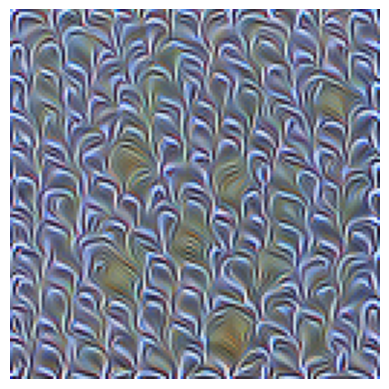

In [7]:
image = render.render_vis(model, f"{layer_name}:{neuron_index}")
print(f"Layer: {layer_name}, Channel: {neuron_index}")
plt.imshow(image[0][0, :, :, :3])
plt.axis('off')
plt.show()

### Findings for Layer conv2d0 go here

In [ ]:
"""
seems to be detecting red/blue edges? not sure why the keyboards are there, go back and add the layer visualization
"""



---



## Layer - conv2d1

### Findings for Layer conv2d1 go here

In [ ]:
"""
seems to be detecting red flowers in grass
"""



---



##  Layer - conv2d2


### Findings for Layer conv2d2 go here

In [ ]:
"""
seems to be detecting dark grey raised edges
"""



---



## Layer - mixed3A


### Findings for Layer mixed3A go here

In [ ]:
"""
black/brown edges?
"""



---



## Layer - mixed3B

### Findings for Layer mixed3B go here

In [ ]:
"""
white edges?
"""



---



## TASK 2

Pick 5 interesting neurons from mixed3B layers of InceptionV1. Repeat the above exercise of finding out what the selected neurons seem to be detecting, use dataset examples to validate your claim.

In [ ]:
# Layer - mixed3B

# Your code goes here

### Findings for Task 2 -> mixed3b's 5 neurons/units go here



---



# TASK 3

Can you find the mixed3b equivalent layer of CLIP Resnet 50 model or any other model of your choice and repeat the exercise from Task 2 for that layer?



In [ ]:
# Your code goes here

#### TEST UNIVERSALITY

Do the units from the mixed3b and it's equivalent layer in model selected for Task 3 seem to be doing similar detections?

*Note* that you may not find the exact same units (ex: eye detector) in both models, a general idea about what kind of features is the model looking for in our layer of interest is enough to check universality wrt Task 3.

### Findings for Task 3 -> Universality Test go here



---

